In [2]:
!pip install numpy pandas matplotlib seaborn tensorflow scikit-learn tensorflow_hub


[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# import library

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import tensorflow_hub as hub

In [4]:
# load dataset
df = pd.read_csv("spam.csv", encoding="latin-1")
# Why we used encoding method?
# Because the dataset contains some special characters that are not supported by the default encoding method.
# By using the latin-1 encoding method, we can read the dataset without any errors.
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [5]:
# Cleaning dataset
# We called it as EDA right? 
# Yes, we can call it as EDA but we will do it in a very simple way. 
# We will just drop the unnecessary columns and rename the columns for better understanding.
# What the difference between cleaning and EDA?
# Cleaning is the process of removing or correcting the errors in the dataset, 
# while EDA is the process of exploring and analyzing the dataset to understand its structure and patterns.

df = df.drop(['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], axis=1)
df = df.rename(columns={'v1': 'label', 'v2': 'Text'}) # Is this also in EDA?
# Yes, this is also part of EDA because we are just renaming the columns for better understanding.
df['label_enc'] = df['label'].map({'ham': 0, 'spam': 1}) # this LOC , we want to change the label column to numerical values, because we will use it for training the model.
df.head()

,label,Text,label_enc
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


In [6]:
X_train, X_test, y_train, y_test = train_test_split(df['Text'],df['label_enc'],test_size=0.2,random_state=42)

# Why we do to_numpy() function
X_train_np = X_train.to_numpy()
X_test_np = X_test.to_numpy()
y_train_np = y_train.to_numpy()
y_test_np = y_test.to_numpy()


In [7]:
avg_words_len = round(sum([len(i.split())
                           for i in df['Text']])/ len(df['Text']))
total_words_length = len(set(" ".join(df['Text']).split()))

print(f"Data Loaded. Training samples: {len(X_train_np)}")
print(f"Average words per message: {avg_words_len}")
print(f"Approximate vocabulary size: {total_words_length}")

Data Loaded. Training samples: 4457
Average words per message: 16
Approximate vocabulary size: 15686


In [8]:
def compile_and_fit(model, epochs=5):
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    history = model.fit(
        X_train_np,
        y_train_np,
        epochs=epochs,
        validation_data=(X_test_np, y_test_np)
    )
    return history

def get_metrics(model, X, y):
    y_preds = np.round(model.predict(X))
    return {
        'accuracy': accuracy_score(y, y_preds),
        'precision': precision_score(y, y_preds),
        'recall': recall_score(y, y_preds),
        'f1-score': f1_score(y, y_preds)
    }

In [9]:
from tensorflow .keras.layers import TextVectorization
text_vec = TextVectorization(
    max_tokens=total_words_length,
    standardize='lower_and_strip_punctuation',
    output_mode='int',
    output_sequence_length=avg_words_len
)
text_vec.adapt(X_train_np)

In [10]:
input_layer = layers.Input(shape=(1,), dtype=tf.string)
x = text_vec(input_layer)
x = layers.Embedding(input_dim=total_words_length, output_dim=128)(x)
x = layers.GlobalAveragePooling1D()(x)
x = layers.Dense(32, activation='relu')(x)
output_layer = layers.Dense(1, activation='sigmoid')(x)

model_1 = keras.Model(input_layer, output_layer, name="Dense_Model")
history_1 = compile_and_fit(model_1)

Epoch 1/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.9033 - loss: 0.2811 - val_accuracy: 0.9605 - val_loss: 0.1419
Epoch 2/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9780 - loss: 0.0858 - val_accuracy: 0.9749 - val_loss: 0.0767
Epoch 3/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9906 - loss: 0.0398 - val_accuracy: 0.9767 - val_loss: 0.0710
Epoch 4/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9944 - loss: 0.0240 - val_accuracy: 0.9776 - val_loss: 0.0644
Epoch 5/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.9971 - loss: 0.0160 - val_accuracy: 0.9785 - val_loss: 0.0703


In [11]:
input_layer = layers.Input(shape=(1,), dtype=tf.string)
x = text_vec(input_layer)
x = layers.Embedding(input_dim=total_words_length, output_dim=128)(x)
x = layers.Bidirectional(layers.LSTM(64, return_sequences=True))(x)
x = layers.Bidirectional(layers.LSTM(64))(x)
x = layers.Flatten()(x)
x = layers.Dropout(0.1)(x)
x = layers.Dense(32, activation='relu')(x)
output_layer = layers.Dense(1, activation='sigmoid')(x)

model_2 = keras.Model(input_layer, output_layer, name="BiLSTM_Model")
history_2 = compile_and_fit(model_2)

Epoch 1/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - accuracy: 0.9444 - loss: 0.1687 - val_accuracy: 0.9812 - val_loss: 0.0710
Epoch 2/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.9895 - loss: 0.0437 - val_accuracy: 0.9848 - val_loss: 0.0610
Epoch 3/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.9969 - loss: 0.0155 - val_accuracy: 0.9821 - val_loss: 0.0648
Epoch 4/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.9982 - loss: 0.0058 - val_accuracy: 0.9821 - val_loss: 0.0926
Epoch 5/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.9982 - loss: 0.0057 - val_accuracy: 0.9794 - val_loss: 0.0906


In [12]:
use_layer = hub.KerasLayer(
    "https://tfhub.dev/google/universal-sentence-encoder/4",
    trainable=False,
    input_shape=[],
    dtype=tf.string,
    name='USE'
)
input_layer = layers.Input(shape=[], dtype=tf.string)
embedding = layers.Lambda(lambda x: use_layer(
    x), output_shape=(512,))(input_layer)
x = layers.Dense(64, activation='relu')(embedding)
x = layers.Dropout(0.2)(x)
output_layer = layers.Dense(1, activation='sigmoid')(x)
model_3 = keras.Model(input_layer, output_layer, name="USE_Model")
history_3 = compile_and_fit(model_3)


Epoch 1/5



140/140 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9212 - loss: 0.2941 - val_accuracy: 0.9749 - val_loss: 0.1130
Epoch 2/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9789 - loss: 0.0817 - val_accuracy: 0.9803 - val_loss: 0.0694
Epoch 3/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9838 - loss: 0.0563 - val_accuracy: 0.9830 - val_loss: 0.0594
Epoch 4/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9865 - loss: 0.0455 - val_accuracy: 0.9839 - val_loss: 0.0541
Epoch 5/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9881 - loss: 0.0400 - val_accuracy: 0.9839 - val_loss: 0.0522


In [14]:
results = {
    'Dense Embedding': get_metrics(model_1, X_test_np, y_test_np),
    'Bi-LSTM': get_metrics(model_2, X_test_np, y_test_np),
    'Transfer Learning (USE)': get_metrics(model_3, X_test_np, y_test_np)
}

results_df = pd.DataFrame(results).transpose()
print("Performance Table:")
print(results_df)

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step
Performance Table:
                         accuracy  precision    recall  f1-score
Dense Embedding          0.978475   0.962963  0.872483  0.915493
Bi-LSTM                  0.979372   0.950000  0.892617  0.920415
Transfer Learning (USE)  0.983857   0.951724  0.926174  0.938776


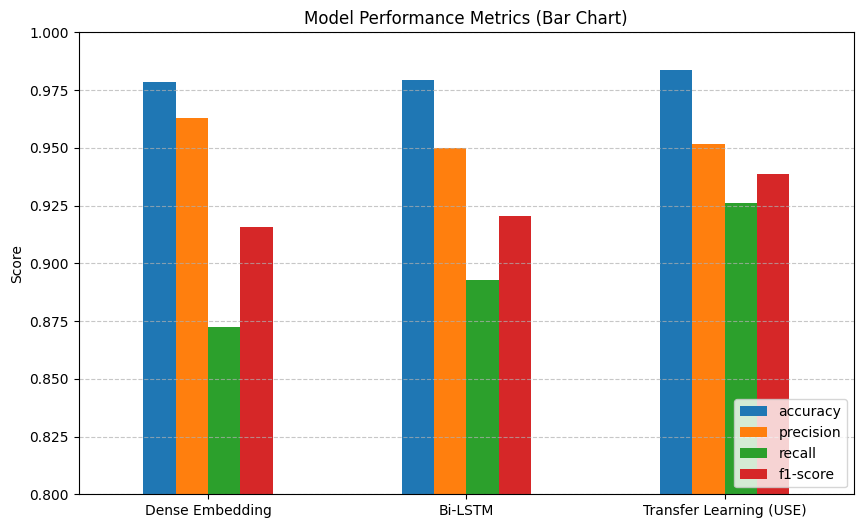

In [16]:
results_df.plot(kind='bar', figsize=(10,6))
plt.title("Model Performance Metrics (Bar Chart)")
plt.ylabel("Score")
plt.ylim(0.8, 1.0)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

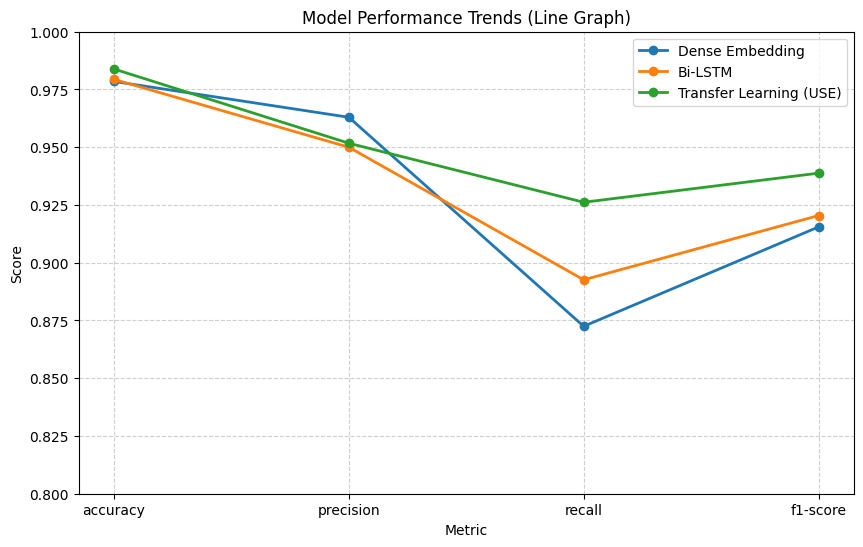

In [17]:
plt.figure(figsize=(10,6))
for model_name in results_df.index:
    plt.plot(
        results_df.columns,
        results_df.loc[model_name],
        marker='o',
        label=model_name,
        linewidth=2
    )
plt.title("Model Performance Trends (Line Graph)")
plt.ylabel("Score")
plt.xlabel("Metric")
plt.ylim(0.8,1.0)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()